In [ ]:
!pip install open3d

In [31]:
!wget https://vision.middlebury.edu/mview/data/data/temple.zip -O /content/temple.zip
!unzip -q /content/temple.zip -d /content/
!ls /content/temple/

--2026-06-22 18:15:37--  https://vision.middlebury.edu/mview/data/data/temple.zip
Resolving vision.middlebury.edu (vision.middlebury.edu)... 140.233.20.14
Connecting to vision.middlebury.edu (vision.middlebury.edu)|140.233.20.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78495639 (75M) [application/zip]
Saving to: ‘/content/temple.zip’

/content/temple.zip 100%[===================>]  74.86M  29.8MB/s    in 2.5s    

2026-06-22 18:15:39 (29.8 MB/s) - ‘/content/temple.zip’ saved [78495639/78495639]

README.txt	temple0063.png	temple0126.png	temple0189.png	temple0252.png
temple0001.png	temple0064.png	temple0127.png	temple0190.png	temple0253.png
temple0002.png	temple0065.png	temple0128.png	temple0191.png	temple0254.png
temple0003.png	temple0066.png	temple0129.png	temple0192.png	temple0255.png
temple0004.png	temple0067.png	temple0130.png	temple0193.png	temple0256.png
temple0005.png	temple0068.png	temple0131.png	temple0194.png	temple0257.png
temple0006.png	templ

In [33]:
import os
os.makedirs('/content/temple_images', exist_ok=True)
os.makedirs('/content/temple_output/sparse', exist_ok=True)

!cp /content/temple/temple*.png /content/temple_images/
print("Images copied:", len(os.listdir('/content/temple_images')))

Images copied: 312


In [34]:
!QT_QPA_PLATFORM=offscreen colmap feature_extractor \
    --database_path /content/temple_output/database.db \
    --image_path /content/temple_images \
    --ImageReader.single_camera 1 \
    --SiftExtraction.use_gpu 0


Feature extraction

Processed file [1/312]
  Name:            temple0001.png
  Dimensions:      640 x 480
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    768.00px
  Features:        1833
Processed file [2/312]
  Name:            temple0002.png
  Dimensions:      640 x 480
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    768.00px
  Features:        1757
Processed file [3/312]
  Name:            temple0003.png
  Dimensions:      640 x 480
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    768.00px
  Features:        1665
Processed file [4/312]
  Name:            temple0004.png
  Dimensions:      640 x 480
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    768.00px
  Features:        1628
Processed file [5/312]
  Name:            temple0005.png
  Dimensions:      640 x 480
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    768.00px
  Features:        1567
Processed file [6/312]
  Name:            temple0006.png
  Dimensions:      640 x 480
  Camera:    

In [35]:
!QT_QPA_PLATFORM=offscreen colmap sequential_matcher \
    --database_path /content/temple_output/database.db \
    --SiftMatching.use_gpu 0


Sequential feature matching

Matching image [1/312] in 3.118s
Matching image [2/312] in 3.140s
Matching image [3/312] in 2.093s
Matching image [4/312] in 1.999s
Matching image [5/312] in 2.126s
Matching image [6/312] in 2.307s
Matching image [7/312] in 2.543s
Matching image [8/312] in 2.641s
Matching image [9/312] in 1.853s
Matching image [10/312] in 1.982s
Matching image [11/312] in 2.076s
Matching image [12/312] in 2.100s
Matching image [13/312] in 2.190s
Matching image [14/312] in 3.469s
Matching image [15/312] in 2.036s
Matching image [16/312] in 2.118s
Matching image [17/312] in 1.898s
Matching image [18/312] in 1.861s
Matching image [19/312] in 1.872s
Matching image [20/312] in 3.005s
Matching image [21/312] in 2.247s
Matching image [22/312] in 1.923s
Matching image [23/312] in 2.499s
Matching image [24/312] in 2.530s
Matching image [25/312] in 2.731s
Matching image [26/312] in 3.963s
Matching image [27/312] in 2.319s
Matching image [28/312] in 2.127s
Matching image [29/312] in 

In [36]:
!QT_QPA_PLATFORM=offscreen colmap mapper \
    --database_path /content/temple_output/database.db \
    --image_path /content/temple_images \
    --output_path /content/temple_output/sparse

Streaming output truncated to the last 5000 lines.
  => Completed observations: 20
  => Filtered observations: 8
  => Changed observations: 0.030074

Bundle adjustment report
------------------------
    Residuals : 8876
   Parameters : 908
   Iterations : 2
         Time : 0.023149 [s]
 Initial cost : 0.396936 [px]
   Final cost : 0.394868 [px]
  Termination : Convergence

  => Merged observations: 0
  => Completed observations: 0
  => Filtered observations: 0
  => Changed observations: 0.000000

Registering image #230 (217)

  => Image sees 547 / 901 points

Pose refinement report
----------------------
    Residuals : 1088
   Parameters : 6
   Iterations : 5
         Time : 0.00542688 [s]
 Initial cost : 0.34439 [px]
   Final cost : 0.339787 [px]
  Termination : Convergence

  => Continued observations: 536
  => Added observations: 189

Bundle adjustment report
------------------------
    Residuals : 8298
   Parameters : 1061
   Iterations : 8
         Time : 0.08584 [s]
 Initial c

In [37]:
!ls /content/temple_output/sparse/0/
print("---")
import struct

def read_points3d_binary(path):
    points = []
    colors = []
    with open(path, 'rb') as f:
        num_points = struct.unpack('Q', f.read(8))[0]
        for _ in range(num_points):
            f.read(8)
            xyz = struct.unpack('ddd', f.read(24))
            rgb = struct.unpack('BBB', f.read(3))
            f.read(8)
            track_length = struct.unpack('Q', f.read(8))[0]
            f.read(8 * track_length)
            points.append(xyz)
            colors.append([r/255.0 for r in rgb])
    import numpy as np
    return np.array(points), np.array(colors)

pts, cols = read_points3d_binary('/content/temple_output/sparse/0/points3D.bin')
print(f"Total 3D points: {len(pts)}")

cameras.bin  images.bin  points3D.bin  project.ini
---
Total 3D points: 30376


In [38]:
import open3d as o3d
import numpy as np

# Load point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(pts)
pcd.colors = o3d.utility.Vector3dVector(cols)

print(f"Before cleaning: {len(pcd.points)} points")

# Statistical outlier removal
pcd_clean, ind = pcd.remove_statistical_outlier(
    nb_neighbors=20,  # look at 20 nearest neighbors
    std_ratio=2.0     # remove if farther than 2 std deviations
)

print(f"After cleaning: {len(pcd_clean.points)} points")
print(f"Removed: {len(pcd.points) - len(pcd_clean.points)} noise points")

# Save cleaned point cloud
o3d.io.write_point_cloud('/content/temple_clean.ply', pcd_clean)
print("Saved temple_clean.ply!")

Before cleaning: 30376 points
After cleaning: 30267 points
Removed: 109 noise points
Saved temple_clean.ply!


In [39]:
import open3d as o3d

# Load cleaned point cloud
pcd_clean = o3d.io.read_point_cloud('/content/temple_clean.ply')
print(f"Loaded: {len(pcd_clean.points)} points")

# Estimate normals
pcd_clean.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30)
)
pcd_clean.orient_normals_consistent_tangent_plane(100)

# Poisson surface reconstruction
print("Building mesh... this takes 2-3 mins")
mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
    pcd_clean, depth=9
)

print(f"Mesh triangles: {len(mesh.triangles)}")
print(f"Mesh vertices: {len(mesh.vertices)}")

# Save
o3d.io.write_triangle_mesh('/content/temple_mesh.ply', mesh)
print("Saved!")

Loaded: 30267 points
Building mesh... this takes 2-3 mins
Mesh triangles: 170095
Mesh vertices: 85170
Saved!


In [40]:
!pip install git+https://github.com/facebookresearch/sam2.git
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth -O /content/sam_vit_b.pth

  Cloning https://github.com/facebookresearch/sam2.git to /tmp/pip-req-build-0djuzxo6
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam2.git /tmp/pip-req-build-0djuzxo6
  Resolved https://github.com/facebookresearch/sam2.git to commit 2b90b9f5ceec907a1c18123530e92e794ad901a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.9 MB/s eta 0:00:00
  Created wheel for SAM-2: filename=sam_2-1.0-py3-none-any.whl size=181433 sha256=da5a2c78676c1434fa331aac2116a96bea58780fd77ed87b09a939d56dfc5634
  Stored in directory: /tmp/pip-ephem-wheel-cache-fbjya1k7/wheels/25/a3/8a/abd69dc6a6926b5e75c24810afac36c7b49b5c0f8a100147d6
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl si

In [43]:
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load SAM
sam = sam_model_registry["vit_b"](checkpoint="/content/sam_vit_b.pth")
sam.to(device="cpu")

mask_generator = SamAutomaticMaskGenerator(sam)

# Load one temple image
img_path = '/content/temple_images/temple0001.png'
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Image shape: {image.shape}")

# Generate masks
print("Running SAM... takes 1-2 mins on CPU")
masks = mask_generator.generate(image)
print(f"Found {len(masks)} segments!")

Image shape: (480, 640, 3)
Running SAM... takes 1-2 mins on CPU
Found 11 segments!


In [42]:
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-rx0e1394
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-rx0e1394
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=e6cb9dd2d7fb6bd9302e16b0c8672a3f62d5166380344fb36f17ee2abc0917a4
  Stored in directory: /tmp/pip-ephem-wheel-cache-skge_tu_/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything


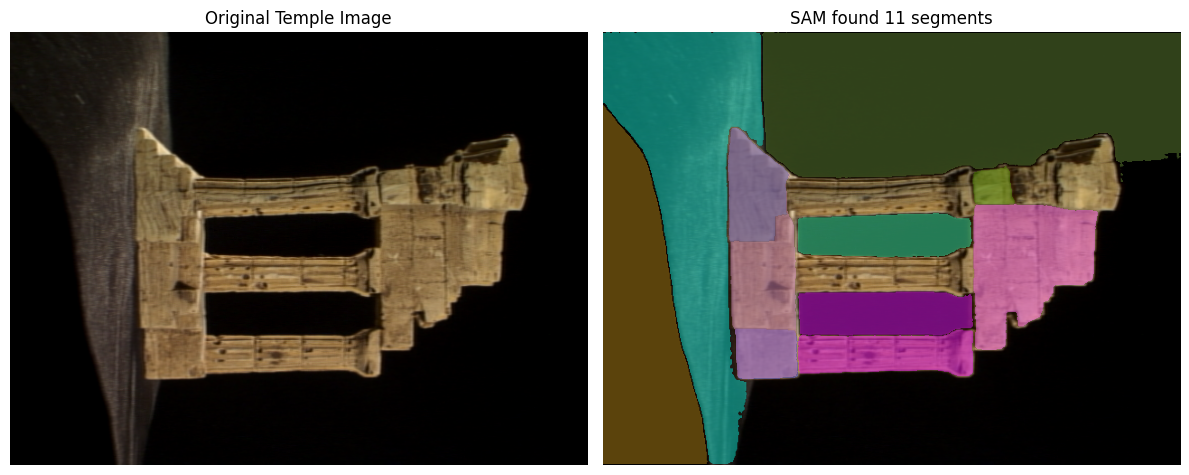

Saved temple_sam.png!


In [44]:
def show_masks(image, masks):
    plt.figure(figsize=(12, 6))

    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title('Original Temple Image')
    plt.axis('off')

    # Masked image
    plt.subplot(1, 2, 2)
    plt.imshow(image)

    # Draw each mask with random color
    for mask in masks:
        color = np.random.random(3)
        m = mask['segmentation']
        colored_mask = np.zeros((*m.shape, 4))
        colored_mask[m] = [*color, 0.5]
        plt.imshow(colored_mask)

    plt.title(f'SAM found {len(masks)} segments')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('/content/temple_sam.png', dpi=150)
    plt.show()
    print("Saved temple_sam.png!")

show_masks(image, masks)

In [45]:
import numpy as np
import open3d as o3d
import struct
import cv2

# Read COLMAP camera info
def read_cameras_binary(path):
    cameras = {}
    with open(path, 'rb') as f:
        num_cameras = struct.unpack('Q', f.read(8))[0]
        for _ in range(num_cameras):
            cam_id = struct.unpack('I', f.read(4))[0]
            model_id = struct.unpack('i', f.read(4))[0]
            width = struct.unpack('Q', f.read(8))[0]
            height = struct.unpack('Q', f.read(8))[0]
            num_params = [3,4,4,5,8,12,3,6,4,4][model_id]
            params = struct.unpack('d'*num_params, f.read(8*num_params))
            cameras[cam_id] = {
                'width': width, 'height': height, 'params': params
            }
    return cameras

cameras = read_cameras_binary('/content/temple_output/sparse/0/cameras.bin')
cam = cameras[1]
fx = cam['params'][0]
cx = cam['params'][1]
cy = cam['params'][2]
print(f"Focal length: {fx:.1f}px")
print(f"Principal point: ({cx:.1f}, {cy:.1f})")
print("Camera loaded!")

Focal length: 1529.0px
Principal point: (320.0, 240.0)
Camera loaded!


In [46]:
# Load cleaned point cloud
pcd = o3d.io.read_point_cloud('/content/temple_clean.ply')
points = np.asarray(pcd.points)
colors = np.asarray(pcd.colors)

# Load one temple image and run SAM
image = cv2.imread('/content/temple_images/temple0001.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Project 3D points onto 2D image
def project_points(points, fx, cx, cy):
    projected = []
    for p in points:
        x, y, z = p
        if z <= 0:
            projected.append((-1, -1))
            continue
        u = int(fx * x / z + cx)
        v = int(fx * y / z + cy)
        projected.append((u, v))
    return projected

proj = project_points(points, fx, cx, cy)
print(f"Projected {len(proj)} points onto image")

# Assign SAM mask label to each 3D point
labels = np.zeros(len(points), dtype=int)
for i, (u, v) in enumerate(proj):
    if 0 <= u < 640 and 0 <= v < 480:
        for mask_id, mask in enumerate(masks):
            if mask['segmentation'][v, u]:
                labels[i] = mask_id + 1
                break

print(f"Labeled points: {np.sum(labels > 0)}")
print(f"Unique segments found in 3D: {len(np.unique(labels))}")

Projected 30267 points onto image
Labeled points: 0
Unique segments found in 3D: 1


In [47]:
def read_images_binary(path):
    images = {}
    with open(path, 'rb') as f:
        num_images = struct.unpack('Q', f.read(8))[0]
        for _ in range(num_images):
            img_id = struct.unpack('I', f.read(4))[0]
            qvec = struct.unpack('dddd', f.read(32))
            tvec = struct.unpack('ddd', f.read(24))
            cam_id = struct.unpack('I', f.read(4))[0]
            name = b''
            while True:
                char = f.read(1)
                if char == b'\x00':
                    break
                name += char
            num_points = struct.unpack('Q', f.read(8))[0]
            f.read(24 * num_points)
            images[img_id] = {
                'name': name.decode(),
                'qvec': qvec,
                'tvec': tvec,
                'cam_id': cam_id
            }
    return images

def qvec_to_rotmat(qvec):
    w, x, y, z = qvec
    R = np.array([
        [1-2*y*y-2*z*z, 2*x*y-2*z*w, 2*x*z+2*y*w],
        [2*x*y+2*z*w, 1-2*x*x-2*z*z, 2*y*z-2*x*w],
        [2*x*z-2*y*w, 2*y*z+2*x*w, 1-2*x*x-2*y*y]
    ])
    return R

images = read_images_binary('/content/temple_output/sparse/0/images.bin')

# Find image 1
img1 = None
for img in images.values():
    if 'temple0001' in img['name']:
        img1 = img
        break

print(f"Found image: {img1['name']}")

# Get rotation and translation
R = qvec_to_rotmat(img1['qvec'])
t = np.array(img1['tvec'])

# Transform 3D points into camera coordinate system
points_cam = (R @ points.T).T + t

# Project onto image
def project_points_cam(points_cam, fx, cx, cy):
    projected = []
    for p in points_cam:
        x, y, z = p
        if z <= 0:
            projected.append((-1, -1))
            continue
        u = int(fx * x / z + cx)
        v = int(fx * y / z + cy)
        projected.append((u, v))
    return projected

proj = project_points_cam(points_cam, fx, cx, cy)

# Check how many fall inside image
valid = [(u,v) for u,v in proj if 0 <= u < 640 and 0 <= v < 480]
print(f"Valid projected points: {len(valid)} out of {len(proj)}")

Found image: temple0001.png
Valid projected points: 30267 out of 30267


In [48]:
# Assign SAM mask label to each 3D point
labels = np.zeros(len(points), dtype=int)

for i, (u, v) in enumerate(proj):
    if 0 <= u < 640 and 0 <= v < 480:
        for mask_id, mask in enumerate(masks):
            if mask['segmentation'][v, u]:
                labels[i] = mask_id + 1
                break

print(f"Labeled points: {np.sum(labels > 0)}")
print(f"Unique segments in 3D: {len(np.unique(labels))}")

# Color each 3D point by its SAM segment
segment_colors = np.random.random((len(masks) + 1, 3))
segment_colors[0] = [0.5, 0.5, 0.5]  # unlabeled = gray

new_colors = np.array([segment_colors[l] for l in labels])

# Save semantic point cloud
pcd_semantic = o3d.geometry.PointCloud()
pcd_semantic.points = o3d.utility.Vector3dVector(points)
pcd_semantic.colors = o3d.utility.Vector3dVector(new_colors)

o3d.io.write_point_cloud('/content/temple_semantic.ply', pcd_semantic)
print("Saved semantic point cloud!")

Labeled points: 17297
Unique segments in 3D: 10
Saved semantic point cloud!


Saved github_banner.png!


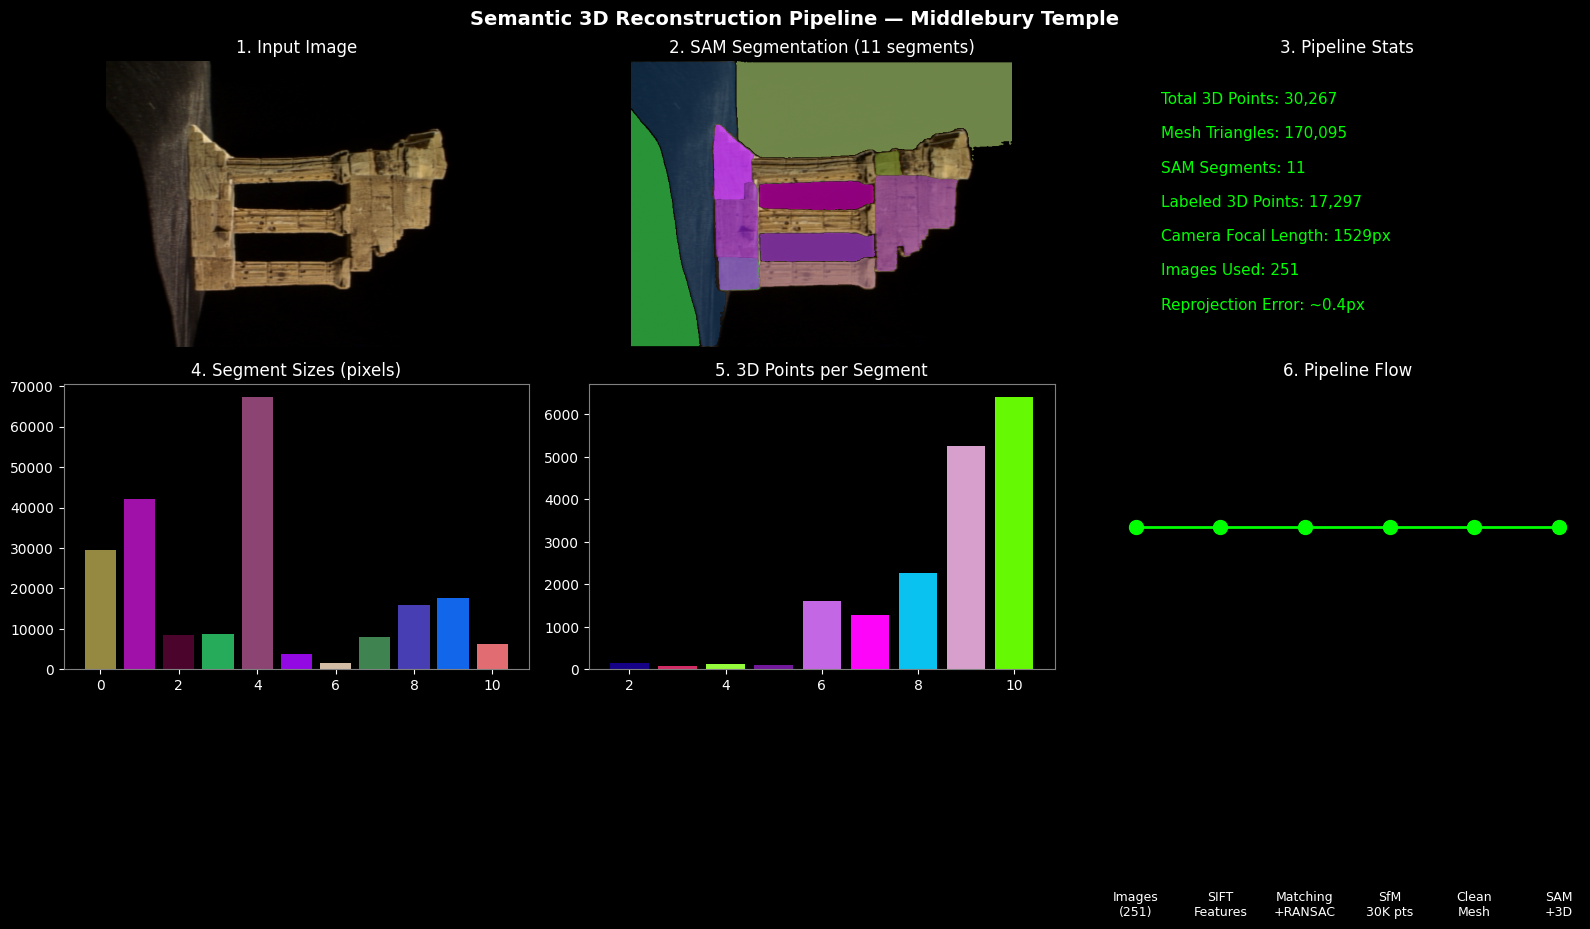

In [49]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('black')

gs = gridspec.GridSpec(2, 3, figure=fig)

# 1. Original image
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(image)
ax1.set_title('1. Input Image', color='white', fontsize=12)
ax1.axis('off')

# 2. SAM segmentation
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(image)
for mask in masks:
    color = np.random.random(3)
    m = mask['segmentation']
    colored_mask = np.zeros((*m.shape, 4))
    colored_mask[m] = [*color, 0.6]
    ax2.imshow(colored_mask)
ax2.set_title('2. SAM Segmentation (11 segments)', color='white', fontsize=12)
ax2.axis('off')

# 3. Point cloud stats
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('black')
stats = [
    f"Total 3D Points: 30,267",
    f"Mesh Triangles: 170,095",
    f"SAM Segments: 11",
    f"Labeled 3D Points: 17,297",
    f"Camera Focal Length: 1529px",
    f"Images Used: 251",
    f"Reprojection Error: ~0.4px",
]
for i, s in enumerate(stats):
    ax3.text(0.1, 0.85 - i*0.12, s, color='lime',
             fontsize=11, transform=ax3.transAxes)
ax3.set_title('3. Pipeline Stats', color='white', fontsize=12)
ax3.axis('off')

# 4. Segment distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor('black')
segment_sizes = [np.sum(m['segmentation']) for m in masks]
colors_bar = [np.random.random(3) for _ in masks]
bars = ax4.bar(range(len(masks)), segment_sizes, color=colors_bar)
ax4.set_title('4. Segment Sizes (pixels)', color='white', fontsize=12)
ax4.tick_params(colors='white')
for spine in ax4.spines.values():
    spine.set_color('gray')

# 5. 3D label distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor('black')
unique, counts = np.unique(labels[labels>0], return_counts=True)
ax5.bar(unique, counts, color=[np.random.random(3) for _ in unique])
ax5.set_title('5. 3D Points per Segment', color='white', fontsize=12)
ax5.tick_params(colors='white')
for spine in ax5.spines.values():
    spine.set_color('gray')

# 6. Pipeline flow
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor('black')
steps = ['Images\n(251)', 'SIFT\nFeatures', 'Matching\n+RANSAC',
         'SfM\n30K pts', 'Clean\nMesh', 'SAM\n+3D']
x = range(len(steps))
ax6.plot(x, [1]*len(steps), 'o-', color='lime', linewidth=2, markersize=10)
for i, s in enumerate(steps):
    ax6.text(i, 0.85, s, ha='center', color='white', fontsize=9)
ax6.set_title('6. Pipeline Flow', color='white', fontsize=12)
ax6.axis('off')

plt.suptitle('Semantic 3D Reconstruction Pipeline — Middlebury Temple',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/github_banner.png', dpi=150,
            bbox_inches='tight', facecolor='black')
print("Saved github_banner.png!")

In [50]:
import os
os.makedirs('/content/outputs', exist_ok=True)

# Copy all output files
import shutil
shutil.copy('/content/github_banner.png', '/content/outputs/github_banner.png')
shutil.copy('/content/temple_sam.png', '/content/outputs/temple_sam.png')
shutil.copy('/content/temple_clean.ply', '/content/outputs/temple_clean.ply')
shutil.copy('/content/temple_mesh.ply', '/content/outputs/temple_mesh.ply')
shutil.copy('/content/temple_semantic.ply', '/content/outputs/temple_semantic.ply')

print("All files copied to outputs folder!")

All files copied to outputs folder!


In [51]:
!zip -r /content/semantic_3d_vision.zip /content/outputs/

from google.colab import files
files.download('/content/semantic_3d_vision.zip')

  adding: content/outputs/ (stored 0%)
  adding: content/outputs/github_banner.png (deflated 5%)
  adding: content/outputs/temple_sam.png (deflated 1%)
  adding: content/outputs/temple_clean.ply (deflated 5%)
  adding: content/outputs/temple_mesh.ply (deflated 64%)
  adding: content/outputs/temple_semantic.ply (deflated 13%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>